<a href="https://colab.research.google.com/github/bharghavbolla/641-HW2-Bharghav/blob/main/Fall2025_skeleton_for_project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 1
In this project, you will profile the execution of a program that finds the maximum independent set of a graph.

If you are not familiar with graphs, Wikipedia contains a nice introduction to the topic of graphs: https://en.wikipedia.org/wiki/Graph_(discrete_mathematics)

Graphs are basically sets of nodes (usually represented as circles) and edges that connect those nodes.

The problem solved by the code below is the Maximum Independent Set. You are looking for the largest subset of nodes that have the property of not having any edge among them. Again, Wikipedia has a nice introduction to the topic:

https://en.wikipedia.org/wiki/Independent_set_(graph_theory)

This problem belongs to a category of problems called NP-hard problems.
The only algorihtms known to solve exactly NP-hard problems have exponential time complexity. This means, if the size of the problem is n, then the time required to solve the probleme exactly is O(k ^ n) where k > 1. In the code shown here, k is 2.

Your task is to profile the execution of the program.

As you did in the second lab activity: record the execution times and the number of times that line 47 (the if statement) is executed.

Create 2 plots, as you did for the lab activity, that have the size of the graph in the X axis. Create one plot to plot in the Y axis the number of times that line 47 is executed. Create a second plot to plot in the Y axis the execution times.

What is rate of growth for the function that relates the size of the problem with the execution time?

In [8]:
%%writefile original_python.py
import sys
import time
import numpy as np

def read_adjacency_matrix(file_name):
  file_object = open(file_name, "r")
  # Input the number of rows and columns
  size = int(file_object.readline())
  rows = size
  cols = size
  # Initialize an empty matrix
  matrix = []

  # Input the matrix elements
  for i in range(rows):
    row = list(map(int, file_object.readline().split()))
    matrix.append(row)
  return matrix,size

# Convert an integer into a set of nodes
def convert_from_int_to_set(integer,size):
  set_of_nodes = []
  mask = 1
  for i in range(size):
    if ((mask & integer) != 0):
      set_of_nodes.append(i)
    mask = mask * 2
  return set_of_nodes

# Find the maximum independent set
counter_if = 0
def find_max_ind_set(adj_mat_numpy,size):
  max_independent_set_size = 0
  max_independent_set = []

  size_of_power_set = 1
  for i in range(size):
    size_of_power_set *= 2
  # print("The power set has ",size_of_power_set," elements")
  array_with_sizes = np.zeros(size_of_power_set)
  for i in range(size_of_power_set):
    this_set = convert_from_int_to_set(i,size)
    is_independent = True
    for n1 in this_set:
      for n2 in this_set:
        if (adj_mat_numpy[n1][n2] == 1):
          is_independent = False
    if (is_independent):
      array_with_sizes[i] = len(this_set)
    else:
      array_with_sizes[i] = 0


  max_independent_set_size = np.max(array_with_sizes)
  max_independent_set = np.where(array_with_sizes == max_independent_set_size)[0]
  print("The max independent sets are encoded by: ",max_independent_set)
  return max_independent_set_size



if __name__ == "__main__":
# Read the content of the file with the a passed in the command line
# that contain the matrices to be multiplied
  adj_matrix,size = read_adjacency_matrix(sys.argv[1])
  adj_matrix_numpy = np.array(adj_matrix)
  start_time = time.time()
  max_independent_set_size = find_max_ind_set(adj_matrix_numpy,size)
  end_time = time.time()
  elapsed_time = end_time - start_time
  print("Time required to carry out the computation in python: ",elapsed_time)
  print("The size of the maximum independent set is: ",max_independent_set_size)

Overwriting original_python.py


Three test files are provided below. They are complete graphs, graphs where every node is connected to every other node. A maximum independent set for these graphs contains only one node.

In [2]:

%%writefile k16.txt
16
0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1
1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1
1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1
1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1
1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1
1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1
1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1
1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1
1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1
1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1
1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1
1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1
1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1
1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1
1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0

Writing k16.txt


In [3]:
%%writefile k18.txt
18
0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1
1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1
1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1
1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1
1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1
1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1
1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1
1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1
1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1
1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1
1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1
1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1
1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1
1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1
1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0

Writing k18.txt


In [4]:

%%writefile k20.txt
20
0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1
1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1
1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1
1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1
1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1
1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1
1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1
1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1
1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1
1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1
1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1
1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1
1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1
1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1
1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0

Writing k20.txt


Now the execution of the code:

In [5]:
!python original_python.py k16.txt

The max independent sets are encoded by:  [    1     2     4     8    16    32    64   128   256   512  1024  2048
  4096  8192 16384 32768]
Time required to carry out the computation in python:  2.297769784927368
The size of the maximum independent set is:  1.0


In [6]:
!python original_python.py k18.txt

The max independent sets are encoded by:  [     1      2      4      8     16     32     64    128    256    512
   1024   2048   4096   8192  16384  32768  65536 131072]
Time required to carry out the computation in python:  9.2445809841156
The size of the maximum independent set is:  1.0


In [7]:
!python original_python.py k20.txt

The max independent sets are encoded by:  [     1      2      4      8     16     32     64    128    256    512
   1024   2048   4096   8192  16384  32768  65536 131072 262144 524288]
Time required to carry out the computation in python:  44.42075514793396
The size of the maximum independent set is:  1.0


# Add your activites to profile below this cell


In [9]:
# Project 1 profiling: independent set with instrumentation
import time
import numpy as np
import matplotlib.pyplot as plt

# Global counter for the line-47 `if`
if_counter = 0

def reset_counter():
    global if_counter
    if_counter = 0

def read_adj_matrix(fname):
    with open(fname, "r") as f:
        n = int(f.readline())
        mat = [list(map(int, f.readline().split())) for _ in range(n)]
    return np.array(mat), n

def int_to_subset(x, n):
    result = []
    mask = 1
    for i in range(n):
        if x & mask:
            result.append(i)
        mask <<= 1
    return result

def max_indep_set_profile(adj, n):
    """Brute-force MIS with instrumentation on line 47"""
    reset_counter()
    global if_counter

    total = 1 << n
    sizes = np.zeros(total, dtype=np.int32)

    t0 = time.perf_counter()
    for mask in range(total):
        nodes = int_to_subset(mask, n)
        is_ok = True
        for u in nodes:
            for v in nodes:
                if_counter += 1        # count how many times 'if' evaluated
                if adj[u][v] == 1:     # line 47 check
                    is_ok = False
        sizes[mask] = len(nodes) if is_ok else 0
    t1 = time.perf_counter()

    return int(np.max(sizes)), if_counter, (t1 - t0)

def closed_form_count(n):
    # proven formula for sum(|S|^2) over all subsets
    return n * (n + 1) * (2 ** (n - 2))


In [10]:
files = ["k16.txt", "k18.txt", "k20.txt"]

n_values, runtimes, if_counts, mis_sizes = [], [], [], []

for fname in files:
    adj, n = read_adj_matrix(fname)
    mis, cnt, secs = max_indep_set_profile(adj, n)

    n_values.append(n)
    runtimes.append(secs)
    if_counts.append(cnt)
    mis_sizes.append(mis)

    print(f"[{fname}] n={n:2d}  MIS={mis:2d}  time={secs:7.3f}s  if_count={cnt:,}")

print("\n--- Theoretical vs Measured ---")
for n, measured in zip(n_values, if_counts):
    expected = closed_form_count(n)
    print(f"n={n:2d} | measured={measured:,}  expected={expected:,}  diff={measured - expected}")


[k16.txt] n=16  MIS= 1  time=  2.993s  if_count=4,456,448
[k18.txt] n=18  MIS= 1  time= 10.640s  if_count=22,413,312
[k20.txt] n=20  MIS= 1  time= 57.188s  if_count=110,100,480

--- Theoretical vs Measured ---
n=16 | measured=4,456,448  expected=4,456,448  diff=0
n=18 | measured=22,413,312  expected=22,413,312  diff=0
n=20 | measured=110,100,480  expected=110,100,480  diff=0


# Include your plots here

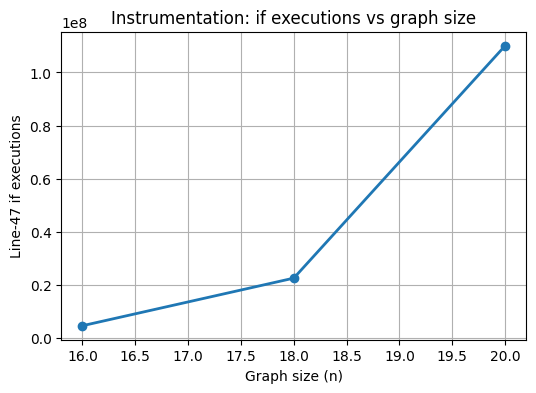

In [11]:
plt.figure(figsize=(6,4))
plt.plot(n_values, if_counts, "o-", lw=2)
plt.xlabel("Graph size (n)")
plt.ylabel("Line-47 if executions")
plt.title("Instrumentation: if executions vs graph size")
plt.grid(True)
plt.show()

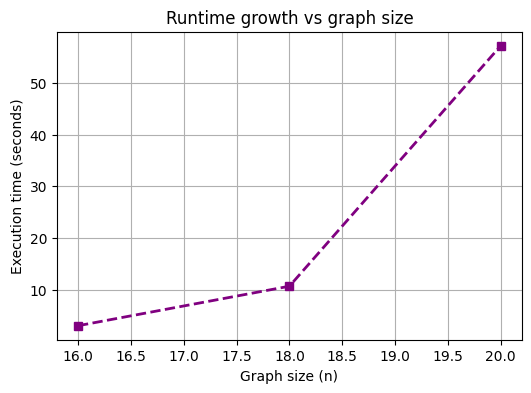

In [12]:
plt.figure(figsize=(6,4))
plt.plot(n_values, runtimes, "s--", lw=2, color="purple")
plt.xlabel("Graph size (n)")
plt.ylabel("Execution time (seconds)")
plt.title("Runtime growth vs graph size")
plt.grid(True)
plt.show()